# fMRI Flanker Pipeline Inspector

Inspect cached step outputs as the cwltool workflow progresses.  
Re-run cells as new steps complete in the cache.

**Pipeline:** BET → MCFLIRT → slicetimer → SUSAN → fslmaths₁(bptf) → fslmaths₂(Tmean) → fslmaths₃(+mean) → FLIRT₁(struct→MNI) → FLIRT₂(func→struct) → FNIRT → applywarp

In [46]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
CACHE_DIR = Path("fmri_flanker_crate/cache")
ADDITIONAL_INPUTS = Path("../fmri_flanker_crate_v2/additional_inputs")
MNI_TEMPLATE = ADDITIONAL_INPUTS / "MNI152_T1_2mm.nii.gz"

def find_cached_files(filename_pattern):
    """Scan cache dirs with 'success' status for files matching a pattern."""
    results = []
    if not CACHE_DIR.exists():
        print("Cache directory not found.")
        return results
    for status_file in sorted(CACHE_DIR.glob("*.status")):
        status = status_file.read_text().strip()
        if status != "success":
            continue
        cache_hash = status_file.stem
        cache_subdir = CACHE_DIR / cache_hash
        if cache_subdir.is_dir():
            matches = list(cache_subdir.glob(filename_pattern))
            for m in matches:
                results.append(m)
    return sorted(results)

def show_slices(img_data, title="", slices=None, cmap="gray", vmin=None, vmax=None):
    """Display axial, coronal, sagittal slices of a 3D volume."""
    if slices is None:
        shape = img_data.shape[:3]
        slices = [s // 2 for s in shape]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(np.rot90(img_data[slices[0], :, :]), cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0].set_title(f"Sagittal (x={slices[0]})")
    axes[1].imshow(np.rot90(img_data[:, slices[1], :]), cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1].set_title(f"Coronal (y={slices[1]})")
    axes[2].imshow(np.rot90(img_data[:, :, slices[2]]), cmap=cmap, vmin=vmin, vmax=vmax)
    axes[2].set_title(f"Axial (z={slices[2]})")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

def show_overlay(bg_data, fg_data, title="", alpha=0.4, fg_cmap="hot", fg_thresh=0.0):
    """Overlay foreground on background at mid-slices."""
    shape = bg_data.shape[:3]
    slices = [s // 2 for s in shape]
    fg_masked = np.ma.masked_where(fg_data <= fg_thresh, fg_data)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, dim, s in zip(axes, ["Sagittal", "Coronal", "Axial"], range(3)):
        idx = [slice(None)] * 3
        idx[s] = slices[s]
        bg_slice = np.rot90(bg_data[tuple(idx)])
        fg_slice = np.rot90(fg_masked[tuple(idx)])
        ax.imshow(bg_slice, cmap="gray")
        ax.imshow(fg_slice, cmap=fg_cmap, alpha=alpha)
        ax.set_title(f"{dim} ({['x','y','z'][s]}={slices[s]})")
        ax.axis("off")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

def show_grid(slices_list, labels, title="", cmap="gray", vmin=None, vmax=None,
              nrows=None, ncols=None):
    """Display a grid of axial slices. Auto-layouts as 1xN, 2x5, etc."""
    n = len(slices_list)
    if nrows is None:
        nrows = 2 if n > 5 else 1
    if ncols is None:
        ncols = int(np.ceil(n / nrows))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = np.atleast_2d(axes)
    for i, (sl, label) in enumerate(zip(slices_list, labels)):
        r, c = divmod(i, ncols)
        axes[r, c].imshow(np.rot90(sl), cmap=cmap, vmin=vmin, vmax=vmax)
        axes[r, c].set_title(label, fontsize=9)
        axes[r, c].axis("off")
    # hide unused axes
    for i in range(n, nrows * ncols):
        r, c = divmod(i, ncols)
        axes[r, c].axis("off")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

def show_overlay_grid(bg_list, fg_list, labels, title="", alpha=0.4,
                      fg_cmap="hot", fg_thresh=0.0, ncols=None):
    """Show overlay of fg on bg for multiple subjects in a 1xN grid."""
    n = len(bg_list)
    if ncols is None:
        ncols = n
    fig, axes = plt.subplots(1, ncols, figsize=(3 * ncols, 3))
    if ncols == 1:
        axes = [axes]
    for i, (bg, fg, label) in enumerate(zip(bg_list, fg_list, labels)):
        fg_masked = np.ma.masked_where(fg <= fg_thresh, fg)
        axes[i].imshow(np.rot90(bg), cmap="gray")
        axes[i].imshow(np.rot90(fg_masked), cmap=fg_cmap, alpha=alpha)
        axes[i].set_title(label, fontsize=9)
        axes[i].axis("off")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

def extract_axial_mid(filepath, vol_index=None):
    """Load a NIfTI, extract mid-axial slice. For 4D, uses vol_index or mid-volume.
    Returns the 2D slice without keeping the full volume in memory."""
    img = nib.load(filepath)
    shape = img.shape
    z_mid = shape[2] // 2
    if len(shape) == 4:
        if vol_index is None:
            vol_index = shape[3] // 2
        data = img.dataobj[:, :, z_mid, vol_index]
    else:
        data = img.dataobj[:, :, z_mid]
    return np.array(data)

# Summary of cache status
status_files = list(CACHE_DIR.glob("*.status")) if CACHE_DIR.exists() else []
success = sum(1 for f in status_files if f.read_text().strip() == "success")
failed = sum(1 for f in status_files if f.read_text().strip() == "permanentFail")
pending = sum(1 for f in status_files if f.read_text().strip() == "")
print(f"Cache: {len(status_files)} entries | {success} success | {failed} failed | {pending} pending")

## Step 1: BET (Brain Extraction)

Expected outputs: `brain.nii.gz`, `brain_mask.nii.gz`

In [ ]:
bet_brains = find_cached_files("brain.nii.gz")
bet_masks = find_cached_files("brain_mask.nii.gz")
print(f"BET: {len(bet_brains)} brain extractions, {len(bet_masks)} masks found")

if bet_brains:
    # All subjects: axial brain slices
    brain_slices = [extract_axial_mid(f) for f in bet_brains]
    labels = [f"Subj {i+1}" for i in range(len(bet_brains))]
    show_grid(brain_slices, labels, title="BET Brain Extraction — All Subjects")

    # All subjects: axial mask overlays
    if bet_masks:
        mask_slices = [extract_axial_mid(f) for f in bet_masks]
        show_overlay_grid(brain_slices, mask_slices, labels,
                          title="BET Brain + Mask Overlay — All Subjects",
                          fg_cmap="cool", alpha=0.3)

    print(f"\nBrain volume stats across {len(bet_brains)} subjects:")
    for i, bf in enumerate(bet_brains):
        bd = nib.load(bf).get_fdata()
        voxel_vol = np.prod(nib.load(bf).header.get_zooms()[:3])
        brain_vol_ml = np.sum(bd > 0) * voxel_vol / 1000
        print(f"  Subject {i+1}: {brain_vol_ml:.1f} mL")
else:
    print("No BET outputs found yet.")

## Step 2: MCFLIRT (Motion Correction)

Expected outputs: `bold_mc.nii.gz`, `bold_mc_mean_reg.nii.gz`, `bold_mc.par`

In [ ]:
mc_means = find_cached_files("bold_mc_mean_reg.nii.gz")
mc_pars = find_cached_files("bold_mc.par")
print(f"MCFLIRT: {len(mc_means)} mean images, {len(mc_pars)} motion parameter files found")

if mc_means:
    # All runs: axial mean images in 2x5 grid
    mean_slices = [extract_axial_mid(f) for f in mc_means]
    labels = [f"Run {i+1}" for i in range(len(mc_means))]
    show_grid(mean_slices, labels, title="MCFLIRT Mean Images — All Runs")

# Motion parameter plots (6 DOF: 3 rotations, 3 translations) — all runs
if mc_pars:
    n_show = len(mc_pars)
    fig, axes = plt.subplots(n_show, 2, figsize=(14, 3 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)
    param_labels_rot = ["Rx (rad)", "Ry (rad)", "Rz (rad)"]
    param_labels_trans = ["Tx (mm)", "Ty (mm)", "Tz (mm)"]

    for i in range(n_show):
        params = np.loadtxt(mc_pars[i])
        for j in range(3):
            axes[i, 0].plot(params[:, j], label=param_labels_rot[j])
            axes[i, 1].plot(params[:, j + 3], label=param_labels_trans[j])
        axes[i, 0].set_ylabel(f"Run {i+1}")
        axes[i, 0].legend(fontsize=8)
        axes[i, 1].legend(fontsize=8)
        if i == 0:
            axes[i, 0].set_title("Rotations")
            axes[i, 1].set_title("Translations")

    axes[-1, 0].set_xlabel("Volume")
    axes[-1, 1].set_xlabel("Volume")
    fig.suptitle("MCFLIRT Motion Parameters — All Runs", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Summary: max absolute displacement per run
    print(f"\nMax absolute motion across {len(mc_pars)} runs:")
    for i, pf in enumerate(mc_pars):
        params = np.loadtxt(pf)
        max_rot = np.max(np.abs(params[:, :3])) * 180 / np.pi
        max_trans = np.max(np.abs(params[:, 3:]))
        print(f"  Run {i+1}: max rotation {max_rot:.2f} deg, max translation {max_trans:.2f} mm")
else:
    print("No MCFLIRT outputs found yet.")

## Step 3: slicetimer (Slice Timing Correction)

Expected output: `bold_st.nii.gz`

In [ ]:
st_files = find_cached_files("bold_st.nii.gz")
mc_bolds = find_cached_files("bold_mc.nii.gz")
print(f"slicetimer: {len(st_files)} outputs found")

if st_files:
    # All runs: axial slices in grid
    st_slices = [extract_axial_mid(f) for f in st_files]
    labels = [f"Run {i+1}" for i in range(len(st_files))]
    show_grid(st_slices, labels, title="slicetimer Output — All Runs")

    # Before/after comparison (first run)
    if mc_bolds:
        mc_data = nib.load(mc_bolds[0]).get_fdata()
        st_data = nib.load(st_files[0]).get_fdata()
        mid_vol = st_data.shape[3] // 2
        z_mid = st_data.shape[2] // 2
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].imshow(np.rot90(mc_data[:, :, z_mid, mid_vol]), cmap="gray")
        axes[0].set_title("Before (MCFLIRT)")
        axes[0].axis("off")
        axes[1].imshow(np.rot90(st_data[:, :, z_mid, mid_vol]), cmap="gray")
        axes[1].set_title("After (slicetimer)")
        axes[1].axis("off")
        fig.suptitle("Slice Timing Correction Comparison (axial, Run 1)", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()
else:
    print("No slicetimer outputs found yet.")

## Step 4: SUSAN (Spatial Smoothing)

Expected output: `bold_smooth.nii.gz`

In [ ]:
susan_files = find_cached_files("bold_smooth.nii.gz")
print(f"SUSAN: {len(susan_files)} outputs found")

if susan_files:
    # All runs: axial slices in grid
    susan_slices = [extract_axial_mid(f) for f in susan_files]
    labels = [f"Run {i+1}" for i in range(len(susan_files))]
    show_grid(susan_slices, labels, title="SUSAN Smoothing Output — All Runs")

    # Before/after comparison (first run)
    if st_files:
        st_data = nib.load(st_files[0]).get_fdata()
        susan_data = nib.load(susan_files[0]).get_fdata()
        mid_vol = susan_data.shape[3] // 2
        z_mid = susan_data.shape[2] // 2
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].imshow(np.rot90(st_data[:, :, z_mid, mid_vol]), cmap="gray")
        axes[0].set_title("Before (slicetimer)")
        axes[0].axis("off")
        axes[1].imshow(np.rot90(susan_data[:, :, z_mid, mid_vol]), cmap="gray")
        axes[1].set_title("After (SUSAN)")
        axes[1].axis("off")
        fig.suptitle("SUSAN Smoothing Comparison (axial, Run 1)", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

    # Intensity stats for all runs
    print(f"\nSUSAN output stats across {len(susan_files)} runs:")
    for i, sf in enumerate(susan_files):
        sd = nib.load(sf).get_fdata()
        print(f"  Run {i+1}: shape={sd.shape}, mean={np.mean(sd[sd > 0]):.1f}, std={np.std(sd[sd > 0]):.1f}")
else:
    print("No SUSAN outputs found yet.")

## Step 5: fslmaths_1 (Temporal Filtering - bptf)

Expected output: `bold_filtered.nii.gz`

**Critical check:** After `bptf 25 -1`, the temporal mean should be approximately **zero** (bptf removes the mean). This is expected and will be restored in Step 7.

In [ ]:
# bptf output has the same name as fslmaths_3 output (bold_filtered.nii.gz)
# Distinguish by checking temporal mean: bptf output has mean ~0, fslmaths_3 has mean ~5000+
all_filtered = find_cached_files("bold_filtered.nii.gz")
bptf_files = []
addmean_files = []

for f in all_filtered:
    data = nib.load(f).get_fdata()
    tmean = np.mean(data[data.shape[0]//2, data.shape[1]//2, data.shape[2]//2, :])
    if abs(tmean) < 100:  # bptf demeaned: temporal mean near 0
        bptf_files.append(f)
    else:  # mean restored: temporal mean ~5000-10000
        addmean_files.append(f)

print(f"fslmaths_1 (bptf): {len(bptf_files)} outputs found")

if bptf_files:
    # All runs: temporal mean maps (should all be ~0)
    bptf_tmean_slices = []
    for f in bptf_files:
        d = nib.load(f).get_fdata()
        tmean_vol = np.mean(d, axis=3)
        z_mid = tmean_vol.shape[2] // 2
        bptf_tmean_slices.append(tmean_vol[:, :, z_mid])
    labels = [f"Run {i+1}" for i in range(len(bptf_files))]
    show_grid(bptf_tmean_slices, labels, title="bptf Temporal Mean — All Runs (should be ~0)",
              cmap="RdBu_r", vmin=-50, vmax=50)

    # Validation for all runs
    print(f"\nbptf validation across {len(bptf_files)} runs:")
    for i, f in enumerate(bptf_files):
        d = nib.load(f).get_fdata()
        tmean_vol = np.mean(d, axis=3)
        brain_mask = tmean_vol != 0
        mean_of_tmean = np.mean(tmean_vol[brain_mask])
        status = "PASS" if abs(mean_of_tmean) < 1.0 else "WARNING"
        print(f"  Run {i+1}: mean of temporal mean = {mean_of_tmean:.4f} [{status}]")
else:
    print("No bptf outputs found yet.")

## Step 6: fslmaths_2 (Temporal Mean of SUSAN output)

Expected output: `mean_func.nii.gz`

Computes `Tmean` of the SUSAN-smoothed data (before bptf). This preserves the positive mean intensity for restoration in Step 7.

In [ ]:
tmean_files = find_cached_files("mean_func.nii.gz")
print(f"fslmaths_2 (Tmean): {len(tmean_files)} outputs found")

if tmean_files:
    # All runs: Tmean volumes
    tmean_slices = [extract_axial_mid(f) for f in tmean_files]
    labels = [f"Run {i+1}" for i in range(len(tmean_files))]
    show_grid(tmean_slices, labels, title="Temporal Mean of SUSAN Output (mean_func) — All Runs")

    # Stats for all runs
    print(f"\nTmean stats across {len(tmean_files)} runs:")
    for i, tf in enumerate(tmean_files):
        td = nib.load(tf).get_fdata()
        brain_mask = td > 0
        mean_val = np.mean(td[brain_mask])
        status = "PASS" if mean_val > 1000 else "WARNING: low intensity"
        print(f"  Run {i+1}: shape={td.shape}, mean={mean_val:.1f}, range=[{np.min(td[brain_mask]):.1f}, {np.max(td[brain_mask]):.1f}] [{status}]")
else:
    print("No Tmean outputs found yet.")

## Step 7: fslmaths_3 (Add Mean Back)

Expected output: `bold_filtered.nii.gz`

**Critical check:** After adding the temporal mean back, the temporal mean should be **positive** (~5000-10000 for typical EPI data). This ensures downstream tools that use intensity-based thresholding (e.g., film_gls) work correctly on the preprocessed output.

In [ ]:
# addmean_files were identified in the Step 5 cell
print(f"fslmaths_3 (+mean): {len(addmean_files)} outputs found")

if addmean_files:
    # All runs: mean-restored volumes
    addmean_slices = []
    for f in addmean_files:
        d = nib.load(f).get_fdata()
        tmean_restored = np.mean(d, axis=3)
        z_mid = tmean_restored.shape[2] // 2
        addmean_slices.append(tmean_restored[:, :, z_mid])
    labels = [f"Run {i+1}" for i in range(len(addmean_files))]
    show_grid(addmean_slices, labels, title="After Mean Restoration — All Runs")

    # Validation for all runs
    print(f"\nMean restoration validation across {len(addmean_files)} runs:")
    for i, f in enumerate(addmean_files):
        d = nib.load(f).get_fdata()
        tmean_restored = np.mean(d, axis=3)
        brain_mask = tmean_restored > 100
        mean_val = np.mean(tmean_restored[brain_mask])
        status = "PASS" if mean_val > 1000 else "FAIL"
        print(f"  Run {i+1}: mean intensity = {mean_val:.1f} [{status}]")
else:
    print("No mean-restored outputs found yet.")

## Step 8: FLIRT_1 (Structural → MNI, 12-DOF)

Expected outputs: `struct2mni_linear.nii.gz`, `struct2mni.mat`

In [ ]:
flirt1_imgs = find_cached_files("struct2mni_linear.nii.gz")
flirt1_mats = find_cached_files("struct2mni.mat")
print(f"FLIRT struct->MNI: {len(flirt1_imgs)} registered images, {len(flirt1_mats)} matrices found")

if flirt1_imgs:
    # All subjects: axial slices
    flirt1_slices = [extract_axial_mid(f) for f in flirt1_imgs]
    labels = [f"Subj {i+1}" for i in range(len(flirt1_imgs))]
    show_grid(flirt1_slices, labels, title="FLIRT struct->MNI (linear) — All Subjects")

    # All subjects: MNI overlay
    if MNI_TEMPLATE.exists():
        mni_data = nib.load(MNI_TEMPLATE).get_fdata()
        z_mni = mni_data.shape[2] // 2
        mni_slice = mni_data[:, :, z_mni]
        bg_list = [mni_slice] * len(flirt1_imgs)
        fg_list = []
        for f in flirt1_imgs:
            d = nib.load(f).get_fdata()
            z_mid = d.shape[2] // 2
            fg_list.append(d[:, :, z_mid])
        show_overlay_grid(bg_list, fg_list, labels,
                          title="MNI Template + FLIRT Registered Structural — All Subjects",
                          fg_cmap="hot", alpha=0.3, fg_thresh=100)
else:
    print("No FLIRT struct->MNI outputs found yet.")

## Step 9: FLIRT_2 (Functional → Structural)

Expected outputs: `func2struct.nii.gz`, `func2struct.mat`

Uses the MCFLIRT mean image (not the 4D timeseries) for better registration quality.

In [ ]:
flirt2_imgs = find_cached_files("func2struct.nii.gz")
flirt2_mats = find_cached_files("func2struct.mat")
print(f"FLIRT func->struct: {len(flirt2_imgs)} registered images, {len(flirt2_mats)} matrices found")

if flirt2_imgs:
    # All runs: axial slices in grid
    flirt2_slices = [extract_axial_mid(f) for f in flirt2_imgs]
    labels = [f"Run {i+1}" for i in range(len(flirt2_imgs))]
    show_grid(flirt2_slices, labels, title="FLIRT func->struct — All Runs")

    # Overlay: one run per subject (every other run = run-1) on T1 brain
    if bet_brains:
        n_subj = len(bet_brains)
        bg_list = []
        fg_list = []
        overlay_labels = []
        for i in range(min(n_subj, len(flirt2_imgs))):
            bd = nib.load(bet_brains[i]).get_fdata()
            z_mid = bd.shape[2] // 2
            bg_list.append(bd[:, :, z_mid])
            fd = nib.load(flirt2_imgs[i]).get_fdata()
            z_mid_f = fd.shape[2] // 2
            fg_list.append(fd[:, :, z_mid_f])
            overlay_labels.append(f"Subj {i+1}")
        show_overlay_grid(bg_list, fg_list, overlay_labels,
                          title="T1 Brain + Registered EPI Overlay — All Subjects",
                          fg_cmap="hot", alpha=0.3, fg_thresh=100)
else:
    print("No FLIRT func->struct outputs found yet.")

## Step 10: FNIRT (Nonlinear Registration)

Expected outputs: `struct2mni.nii.gz`, `struct2mni_warp.nii.gz`

Uses `T1_2_MNI152_2mm.cnf` config for optimized T1→MNI152 registration.

In [ ]:
fnirt_imgs = find_cached_files("struct2mni.nii.gz")
fnirt_warps = find_cached_files("struct2mni_warp.nii.gz")
print(f"FNIRT: {len(fnirt_imgs)} warped images, {len(fnirt_warps)} warp fields found")

if fnirt_imgs:
    # All subjects: axial slices
    fnirt_slices = [extract_axial_mid(f) for f in fnirt_imgs]
    labels = [f"Subj {i+1}" for i in range(len(fnirt_imgs))]
    show_grid(fnirt_slices, labels, title="FNIRT Nonlinear Registration — All Subjects")

    # All subjects: MNI overlay
    if MNI_TEMPLATE.exists():
        mni_data = nib.load(MNI_TEMPLATE).get_fdata()
        z_mni = mni_data.shape[2] // 2
        mni_slice = mni_data[:, :, z_mni]
        bg_list = [mni_slice] * len(fnirt_imgs)
        fg_list = []
        for f in fnirt_imgs:
            d = nib.load(f).get_fdata()
            z_mid = d.shape[2] // 2
            fg_list.append(d[:, :, z_mid])
        show_overlay_grid(bg_list, fg_list, labels,
                          title="MNI Template + FNIRT Registered Structural — All Subjects",
                          fg_cmap="hot", alpha=0.3, fg_thresh=100)

        # Linear vs nonlinear comparison for all subjects
        if flirt1_imgs:
            n_subj = len(fnirt_imgs)
            fig, axes = plt.subplots(2, n_subj, figsize=(3 * n_subj, 6))
            if n_subj == 1:
                axes = axes.reshape(2, 1)
            for i in range(n_subj):
                flirt1_data = nib.load(flirt1_imgs[i]).get_fdata()
                fnirt_data = nib.load(fnirt_imgs[i]).get_fdata()
                z_f1 = flirt1_data.shape[2] // 2
                z_fn = fnirt_data.shape[2] // 2
                axes[0, i].imshow(np.rot90(flirt1_data[:, :, z_f1]), cmap="gray")
                axes[0, i].set_title(f"Subj {i+1}", fontsize=9)
                axes[0, i].axis("off")
                axes[1, i].imshow(np.rot90(fnirt_data[:, :, z_fn]), cmap="gray")
                axes[1, i].axis("off")
            axes[0, 0].set_ylabel("FLIRT (linear)", fontsize=10)
            axes[1, 0].set_ylabel("FNIRT (nonlinear)", fontsize=10)
            for row in range(2):
                axes[row, 0].tick_params(left=False, labelleft=False)
            fig.suptitle("Linear vs Nonlinear Registration — All Subjects", fontsize=13, fontweight="bold")
            plt.tight_layout()
            plt.show()
else:
    print("No FNIRT outputs found yet.")

## Step 11: applywarp (Functional → MNI Space)

Expected output: `bold_mni.nii.gz`

Applies the combined func→struct→MNI warp to the 4D filtered BOLD.

In [ ]:
warp_files = find_cached_files("bold_mni.nii.gz")
print(f"applywarp: {len(warp_files)} outputs found")

if warp_files:
    # All runs: axial slices in grid
    warp_slices = [extract_axial_mid(f) for f in warp_files]
    labels = [f"Run {i+1}" for i in range(len(warp_files))]
    show_grid(warp_slices, labels, title="Functional in MNI Space — All Runs")

    # MNI overlay for one run per subject (first 5)
    if MNI_TEMPLATE.exists():
        mni_data = nib.load(MNI_TEMPLATE).get_fdata()
        z_mni = mni_data.shape[2] // 2
        mni_slice = mni_data[:, :, z_mni]
        n_overlay = min(5, len(warp_files))
        bg_list = [mni_slice] * n_overlay
        fg_list = [warp_slices[i] for i in range(n_overlay)]
        overlay_labels = [f"Run {i+1}" for i in range(n_overlay)]
        show_overlay_grid(bg_list, fg_list, overlay_labels,
                          title="MNI Template + Functional Overlay",
                          fg_cmap="hot", alpha=0.3, fg_thresh=100)

    # FOV coverage stats for all runs
    print(f"\napplywarp FOV coverage across {len(warp_files)} runs:")
    for i, wf in enumerate(warp_files):
        wd = nib.load(wf).get_fdata()
        tmean_warp = np.mean(wd, axis=3)
        total_voxels = np.prod(tmean_warp.shape)
        nonzero_voxels = np.sum(tmean_warp != 0)
        print(f"  Run {i+1}: shape={wd.shape}, {100*nonzero_voxels/total_voxels:.1f}% non-zero")
else:
    print("No applywarp outputs found yet.")

## Summary

Re-run the cell below after the workflow completes to get a full pipeline summary.

In [60]:
print("=" * 60)
print("FLANKER PREPROCESSING PIPELINE SUMMARY")
print("=" * 60)

steps = [
    ("BET (brain extraction)", "brain.nii.gz"),
    ("MCFLIRT (motion correction)", "bold_mc_mean_reg.nii.gz"),
    ("slicetimer", "bold_st.nii.gz"),
    ("SUSAN (smoothing)", "bold_smooth.nii.gz"),
    ("fslmaths_1 (bptf)", "bold_filtered.nii.gz"),
    ("fslmaths_2 (Tmean)", "mean_func.nii.gz"),
    ("FLIRT struct->MNI", "struct2mni.mat"),
    ("FLIRT func->struct", "func2struct.mat"),
    ("FNIRT", "struct2mni_warp.nii.gz"),
    ("applywarp", "bold_mni.nii.gz"),
]

for name, pattern in steps:
    found = find_cached_files(pattern)
    status = f"{len(found)} outputs" if found else "not found"
    marker = "OK" if found else "--"
    print(f"  [{marker:>2}] {name:<30} {status}")

# Key validation checks
print("\n" + "=" * 60)
print("KEY VALIDATION CHECKS")
print("=" * 60)

warp_files = find_cached_files("bold_mni.nii.gz")
if warp_files:
    wd = nib.load(warp_files[0]).get_fdata()
    tmean_w = np.mean(wd, axis=3)
    total = np.prod(tmean_w.shape)
    nonzero = np.sum(tmean_w != 0)
    print(f"  applywarp FOV coverage: {100*nonzero/total:.1f}% non-zero")
    print(f"  applywarp outputs: {len(warp_files)} PASS" if len(warp_files) > 0 else "  applywarp: FAIL")
else:
    print("  applywarp: not yet available")

# Check mean restoration
all_filtered = find_cached_files("bold_filtered.nii.gz")
restored = [f for f in all_filtered
            if abs(np.mean(nib.load(f).get_fdata()[
                nib.load(f).get_fdata().shape[0]//2,
                nib.load(f).get_fdata().shape[1]//2,
                nib.load(f).get_fdata().shape[2]//2, :])) >= 100]
print(f"  Mean-restored filtered BOLDs: {len(restored)}")

print("=" * 60)

FLANKER PREPROCESSING PIPELINE SUMMARY
  [OK] BET (brain extraction)         5 outputs
  [OK] MCFLIRT (motion correction)    10 outputs
  [OK] slicetimer                     10 outputs
  [OK] SUSAN (smoothing)              10 outputs
  [OK] fslmaths_1 (bptf)              20 outputs
  [OK] fslmaths_2 (Tmean)             10 outputs
  [OK] FLIRT struct->MNI              5 outputs
  [OK] FLIRT func->struct             10 outputs
  [OK] FNIRT                          5 outputs
  [OK] applywarp                      10 outputs

KEY VALIDATION CHECKS
  applywarp FOV coverage: 99.0% non-zero
  applywarp outputs: 10 PASS
  Mean-restored filtered BOLDs: 10


---

## Figure 6B: Preprocessing Stages Panel

Publication-quality grouped-stages layout for the paper figure.

**6 panels in 3 stage groups:**
- **Extraction & Motion:** BET | MCFLIRT
- **Spatial Processing:** SUSAN | FLIRT (func→struct)
- **Standard Space:** FNIRT | applywarp

Conventions: Garamond font, no titles on individual panels, SVG export.

In [61]:
import matplotlib
import matplotlib.font_manager as fm

# --- Font setup: use Garamond if available, fall back to serif ---
garamond_candidates = [f.fname for f in fm.fontManager.ttflist
                       if "garamond" in f.name.lower()]
if garamond_candidates:
    garamond_prop = fm.FontProperties(fname=garamond_candidates[0])
    font_family = garamond_prop.get_name()
else:
    font_family = "serif"

plt.rcParams.update({
    "font.family": font_family,
    "font.size": 11,
    "axes.titlesize": 12,
    "svg.fonttype": "none",        # editable text in SVG
})

# --- Collect representative data for each panel ---
panel_data = {}

# 1. BET: skull-stripped brain (3D)
_bet = find_cached_files("brain.nii.gz")
if _bet:
    panel_data["BET"] = nib.load(_bet[0]).get_fdata()

# 2. MCFLIRT: mean image after motion correction (3D)
_mc = find_cached_files("bold_mc_mean_reg.nii.gz")
if _mc:
    panel_data["MCFLIRT"] = nib.load(_mc[0]).get_fdata()

# 3. SUSAN: smoothed BOLD mid-volume (take temporal mid-point -> 3D)
_sus = find_cached_files("bold_smooth.nii.gz")
if _sus:
    _d = nib.load(_sus[0]).get_fdata()
    panel_data["SUSAN"] = _d[:, :, :, _d.shape[3] // 2]

# 4. FLIRT func->struct: registered EPI in structural space (3D)
_f2s = find_cached_files("func2struct.nii.gz")
if _f2s:
    panel_data["FLIRT"] = nib.load(_f2s[0]).get_fdata()

# 5. FNIRT: nonlinear-registered structural in MNI space (3D)
_fnirt = find_cached_files("struct2mni.nii.gz")
if _fnirt:
    panel_data["FNIRT"] = nib.load(_fnirt[0]).get_fdata()

# 6. applywarp: functional in MNI space, temporal mean (3D)
_aw = find_cached_files("bold_mni.nii.gz")
if _aw:
    _d = nib.load(_aw[0]).get_fdata()
    panel_data["applywarp"] = np.mean(_d, axis=3)

# MNI template for underlay in standard-space panels
_mni = nib.load(MNI_TEMPLATE).get_fdata() if MNI_TEMPLATE.exists() else None

print(f"Panels loaded: {list(panel_data.keys())} ({len(panel_data)}/6)")

Panels loaded: ['BET', 'MCFLIRT', 'SUSAN', 'FLIRT', 'FNIRT', 'applywarp'] (6/6)


Saved: figure_6b_preprocessing_stages.svg


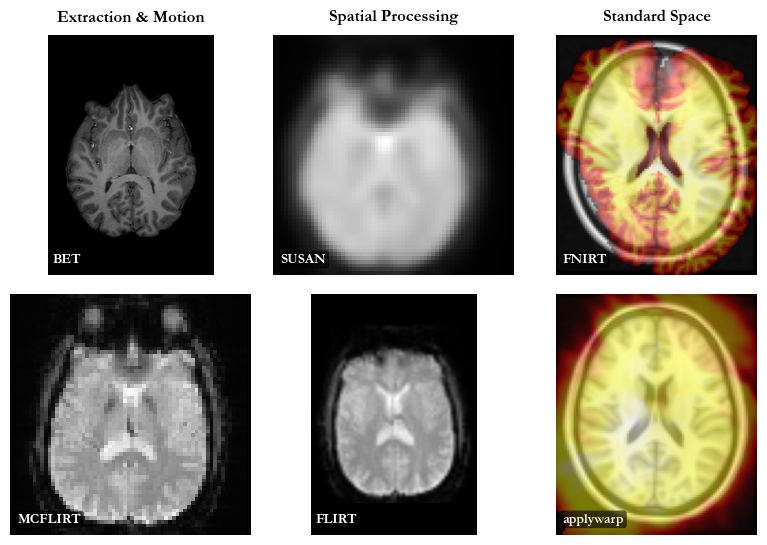

In [62]:
# ── Figure 6B: Grouped preprocessing stages (3 groups x 2 panels) ──
#
# Layout:  3 columns (stage groups) x 1 row
#   Each column shows an axial slice from two representative steps.
#   Stage group labels span the column pair.

panel_order = ["BET", "MCFLIRT", "SUSAN", "FLIRT", "FNIRT", "applywarp"]
stage_groups = [
    ("Extraction & Motion",  ["BET", "MCFLIRT"]),
    ("Spatial Processing",   ["SUSAN", "FLIRT"]),
    ("Standard Space",       ["FNIRT", "applywarp"]),
]

# Verify all panels available
missing = [k for k in panel_order if k not in panel_data]
if missing:
    print(f"WARNING: missing panels {missing} — figure will have blank slots")

fig, axes = plt.subplots(2, 3, figsize=(10, 6.5),
                         gridspec_kw={"hspace": 0.08, "wspace": 0.06})

for col, (group_label, keys) in enumerate(stage_groups):
    for row, key in enumerate(keys):
        ax = axes[row, col]
        if key in panel_data:
            vol = panel_data[key]
            z_mid = vol.shape[2] // 2

            # For standard-space panels, show MNI underlay + overlay
            if key in ("FNIRT", "applywarp") and _mni is not None:
                z_mni = _mni.shape[2] // 2
                ax.imshow(np.rot90(_mni[:, :, z_mni]), cmap="gray",
                          aspect="equal")
                fg = np.ma.masked_where(vol[:, :, z_mid] <= 0,
                                        vol[:, :, z_mid])
                ax.imshow(np.rot90(fg), cmap="hot", alpha=0.45,
                          aspect="equal")
            else:
                ax.imshow(np.rot90(vol[:, :, z_mid]), cmap="gray",
                          aspect="equal")

            # Step label in lower-left
            ax.text(0.03, 0.04, key, transform=ax.transAxes,
                    fontsize=10, color="white", fontweight="bold",
                    va="bottom", ha="left",
                    bbox=dict(boxstyle="round,pad=0.2", fc="black",
                              alpha=0.6, ec="none"))
        else:
            ax.text(0.5, 0.5, f"{key}\n(not available)",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=10, color="#888")
        ax.axis("off")

    # Stage group label spanning both rows (placed above column)
    mid_y = 1.06
    axes[0, col].set_title(group_label, fontsize=12, fontweight="bold",
                           pad=10)

plt.savefig("figure_6b_preprocessing_stages.svg",
            format="svg", bbox_inches="tight", dpi=150, transparent=True)
print("Saved: figure_6b_preprocessing_stages.svg")
plt.show()